# Phase 5: Modeling

Phases 0-4 (data audit/rebuild, feature engineering, deep EDA, statistical validation) and
Phase 3.5 (derived metrics) are done. This notebook builds two deliverables (`plan.md` §6):

1. **5A — Rating prediction**, in two deliberately separate framings: *descriptive*
   (`Log_Votes` allowed — "what characterizes highly-rated restaurants?") and *actionable*
   (`Log_Votes` excluded as leakage — "what levers does an owner actually control?"). The
   actionable R² is expected around 0.3-0.4; that is the honest finding, not a shortfall.
2. **5B — Cold-start classifier**: which restaurants never receive a single rating? A binary
   `Is Rated` classifier on all 8,643 rows.

**Ground rules carried over from Phase 3/4/3.5:**
- `Log_Votes`/`Votes` is leakage for the actionable rating model (Phase 4: correlation collapses
  0.296 → 0.031 once restricted to `df_rated`) and is *undefined/trivial* for unrated
  restaurants (leakage for 5B too) — excluded from both.
- `Average Cost for two` and `Price range` are near-redundant (Spearman ρ = 0.83-0.91) — only
  `Price range` is used as the control.
- NCR is 91.95% of the data and the non-NCR sample is small and skews popular (Phase 4 §5.1) —
  every model reports NCR-vs-non-NCR performance separately, not just an overall number.
- `Primary Cuisine` (74 unique) and `Locality` (783 unique) are too high-cardinality for
  one-hot — target/frequency encoding is used instead, fit only on the training fold each
  time (the single highest leakage risk in this notebook, called out explicitly below).
- No grid search, no repeated CV anywhere — fixed, constrained hyperparameters throughout.
  Headline numbers are directional/analysis-grade, not a tuned deployable model.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix)
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor, XGBClassifier

# Chart styling: same editorial palette as Derived_Metrics.ipynb -- no new color needed here.
ACCENT = '#2a78d6'
WARN = '#c1502e'
INK = '#0b0b0b'
INK_2 = '#52514e'
MUTED = '#898781'
GRID = '#e1e0d9'
AXIS = '#c3c2b7'
SURFACE = '#fcfcfb'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 1, 'grid.linestyle': '-',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold', 'axes.titlecolor': INK,
})

**A note on SHAP:** `shap` is not installed in this environment, and this notebook does not
add a new dependency for it. Permutation importance — computed on the held-out test set,
through the full fitted pipeline, on raw un-encoded columns — already answers "which raw lever
matters" at the fidelity this analysis needs, consistent with the project's scipy/statsmodels
-first, minimal-new-dependency convention (`Derived_Metrics.ipynb` made the same call about
`sklearn.linear_model`).

In [2]:
# Output/ CSVs are written by pandas as UTF-8 (only the raw zomato.csv needs latin-1)
df = pd.read_csv('Output/df_featured.csv')
RATING = 'Aggregate rating'
ALPHA = 0.05

print(f"All rows: {len(df):,} | Rated rows: {df['Is Rated'].sum():,} | Unrated rows: {(~df['Is Rated']).sum():,}")
print(f"Rating range (rated only): {df.loc[df['Is Rated'], RATING].min()} - {df.loc[df['Is Rated'], RATING].max()}")

All rows: 8,643 | Rated rows: 6,504 | Unrated rows: 2,139
Rating range (rated only): 1.8 - 4.9


### Observation:
8,643 total restaurants split into 6,504 rated / 2,139 unrated — identical to every earlier
notebook's split. Rated restaurants range from 1.8 to 4.9, confirming the loaded base is the
same fixed data every prior phase used.

## 0. Merging Phase 3.5 features

Two Phase 3.5 outputs are restaurant-level and safe to bring in as features/targets:
`competition_density.csv` (leakage-safe static geography, joined onto **all** of `df` since it
covers rated and unrated NCR restaurants alike) and `credibility_weighted_ratings.csv`
(`Cred_Rating`, joined onto `df_rated` only, used later strictly as an **alternate target**,
never a feature -- it's near-tautological with `Aggregate rating`).

**Deliberately NOT merged:** `value_for_money_residuals.csv` (`Residual`/`Predicted_Rating` are
*derived from* `Cred_Rating` -- circular as a feature), and `cuisine_pair_premium.csv` /
`locality_cuisine_crosstab.csv` / `locality_pricerange_crosstab.csv` / `locality_opportunity_flags.csv`
(composite-keyed locality/pair aggregates, not restaurant-level -- Phase 6 business-narrative
material, not model inputs). Stating this once here heads off the most likely accidental-leakage
mistake in this notebook.

In [3]:
density_df = pd.read_csv('Output/competition_density.csv')[
    ['Restaurant ID', 'Competitors_500m', 'Competitors_1km', 'Competitors_2km']]
df = df.merge(density_df, on='Restaurant ID', how='left')
df['Has_Density_Data'] = df['Competitors_1km'].notna()
for col in ['Competitors_500m', 'Competitors_1km', 'Competitors_2km']:
    df[col] = df[col].fillna(0)

# df_rated is (re)built here, AFTER the density merge, so it inherits Competitors_*/Has_Density_Data
df_rated = df[df['Is Rated']].copy()

cred_df = pd.read_csv('Output/credibility_weighted_ratings.csv')[['Restaurant ID', 'Cred_Rating', 'shrinkage_weight']]
df_rated = df_rated.merge(cred_df, on='Restaurant ID', how='left')

print(f"df: {df.shape}, df_rated: {df_rated.shape}")
print(f"Restaurants with density data: {df['Has_Density_Data'].sum():,} of {len(df):,} ({df['Has_Density_Data'].mean():.1%})")
print(f"df_rated rows missing Cred_Rating after merge: {df_rated['Cred_Rating'].isna().sum()}")

df: (8643, 28), df_rated: (6504, 30)
Restaurants with density data: 7,550 of 8,643 (87.4%)
df_rated rows missing Cred_Rating after merge: 0


### Observation:
`df` gains 5 columns (28 total: the original 24 minus none, plus `Competitors_500m/1km/2km` and
`Has_Density_Data`); `df_rated` gains those 5 plus `Cred_Rating`/`shrinkage_weight` (30 total).
87.4% of all restaurants (7,550 of 8,643) have real density data — the rest are outside NCR and
get `Competitors_* = 0` with `Has_Density_Data = False`, exactly as planned. Zero rows in
`df_rated` are missing `Cred_Rating` after the merge, confirming the join is complete for every
rated restaurant.

## 1. Ground rules & feature framing

Both 5A framings run on `df_rated` only — `Aggregate rating` is undefined for unrated
restaurants. **Target-encoding leakage rule** (stated once, applies everywhere below):
`sklearn.preprocessing.TargetEncoder` is fit only inside the pipeline's `.fit(X_train, y_train)`
call (which internally cross-fits with its own 5-fold split), and applied to test/validation
data only via that already-fitted transform — it is never refit on test data.

| Feature | Descriptive | Actionable | Notes |
|---|---|---|---|
| `Price range` | ✓ | ✓ | control; chosen over cost (ρ = 0.83-0.91 redundant, Phase 3/4) |
| `Is NCR` | ✓ | ✓ | control (Phase 4 §5.1) |
| `Has Table booking` | ✓ | ✓ | Simpson's-paradox proxy for price+region — the model can use it as a proxy, but it isn't an independent lever (Phase 4) |
| `Has Online delivery` | ✓ | ✓ | |
| `Is Chain` | ✓ | ✓ | chosen over `n_outlets` (same information) |
| `Cuisines Count` | ✓ | ✓ | |
| `Primary Cuisine` (target-encoded) | ✓ | ✓ | 74 unique — target encoding, not one-hot |
| `Locality` (target-encoded) | ✓ | ✓ | 783 unique (102 with ≥30 rows) — same reason |
| `Competitors_1km` + `Has_Density_Data` | ✓ | ✓ | leakage-safe (static geography, Phase 3.5) |
| `Log_Votes` | ✓ | ✗ | leakage — Phase 4 correlation collapse |
| `Average Cost for two`, `Log_Cost`, `City`, `n_outlets`, `Latitude`/`Longitude`, `density_tier` | ✗ | ✗ | redundant / not merged / superseded |
| `Cred_Rating` | target only | target only | never a feature under either framing (near-tautological) |
| `Residual`, `Predicted_Rating` | ✗ | ✗ | circular — never merged (§0) |

## 2. 5A: Rating prediction

In [4]:
FEATURES_DESCRIPTIVE = ['Price range', 'Is NCR', 'Has Table booking', 'Has Online delivery',
                        'Is Chain', 'Cuisines Count', 'Primary Cuisine', 'Locality',
                        'Competitors_1km', 'Has_Density_Data', 'Log_Votes']
FEATURES_ACTIONABLE = ['Price range', 'Is NCR', 'Has Table booking', 'Has Online delivery',
                       'Is Chain', 'Cuisines Count', 'Primary Cuisine', 'Locality',
                       'Competitors_1km', 'Has_Density_Data']
CAT_COLS = ['Primary Cuisine', 'Locality']

def build_pipeline(estimator, target_type='continuous'):
    ct = ColumnTransformer(
        [('cat', TargetEncoder(target_type=target_type, random_state=42), CAT_COLS)],
        remainder='passthrough')
    return Pipeline([('encode', ct), ('model', estimator)])

def regression_metrics(y_true, y_pred):
    return {'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)}

print("Descriptive features:", FEATURES_DESCRIPTIVE)
print("Actionable features:", FEATURES_ACTIONABLE)

Descriptive features: ['Price range', 'Is NCR', 'Has Table booking', 'Has Online delivery', 'Is Chain', 'Cuisines Count', 'Primary Cuisine', 'Locality', 'Competitors_1km', 'Has_Density_Data', 'Log_Votes']
Actionable features: ['Price range', 'Is NCR', 'Has Table booking', 'Has Online delivery', 'Is Chain', 'Cuisines Count', 'Primary Cuisine', 'Locality', 'Competitors_1km', 'Has_Density_Data']


### Observation:
The only difference between the two framings is `Log_Votes` — everything else (control
variables, target-encoded categoricals, the Phase 3.5 density feature) is identical, so any gap
between the two models' performance later is attributable to vote information alone, not to a
different feature set elsewhere.

In [5]:
X_desc = df_rated[FEATURES_DESCRIPTIVE]
X_act = df_rated[FEATURES_ACTIONABLE]
y = df_rated[RATING]
ncr = df_rated['Is NCR']

strat_bins = pd.cut(y, bins=5)
idx_train, idx_test = train_test_split(df_rated.index, test_size=0.2, random_state=42, stratify=strat_bins)

X_desc_train, X_desc_test = X_desc.loc[idx_train], X_desc.loc[idx_test]
X_act_train, X_act_test = X_act.loc[idx_train], X_act.loc[idx_test]
y_train, y_test = y.loc[idx_train], y.loc[idx_test]
ncr_test = ncr.loc[idx_test]

print(f"Train: {len(idx_train):,} rows | Test: {len(idx_test):,} rows")
print(f"Test set -- NCR: {ncr_test.sum():,} | Non-NCR: {(~ncr_test).sum():,}")

Train: 5,203 rows | Test: 1,301 rows
Test set -- NCR: 1,162 | Non-NCR: 139


### Observation:
80/20 split gives 5,203 training rows and 1,301 test rows. The test set's NCR/non-NCR split
(1,162 vs 139) mirrors the population's 91.95%/8.05% ratio, but 139 rows is still a thin slice —
any non-NCR performance number below should be read as directional, consistent with Phase 4's
own caution about the small, curated non-NCR sample.

In [6]:
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_metrics = regression_metrics(y_test, baseline_pred)

print(f"Baseline (predict train mean = {y_train.mean():.3f}):")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nAggregate rating std on df_rated: {y.std():.3f}  (context for judging RMSE)")

Baseline (predict train mean = 3.352):
  RMSE: 0.5067
  MAE: 0.4100
  R2: -0.0001

Aggregate rating std on df_rated: 0.504  (context for judging RMSE)


### Observation:
Predicting the training mean (3.352) for every test restaurant gives RMSE 0.507 and R²
≈ 0 (by construction, on a slightly different test mean) — the honest floor every real model
must beat. `Aggregate rating`'s own standard deviation (0.504) is almost identical to the
baseline RMSE, which is the expected relationship: a mean-only prediction's error is roughly the
target's own spread.

In [7]:
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                           random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, random_state=42),
}
framings = {
    'Descriptive': (X_desc_train, X_desc_test),
    'Actionable': (X_act_train, X_act_test),
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results_5a = []
fitted_pipelines = {}
for framing_name, (Xtr, Xte) in framings.items():
    for model_name, estimator_template in models.items():
        pipe = build_pipeline(clone(estimator_template), target_type='continuous')

        cv_rmses = []
        for tr_idx, val_idx in kf.split(Xtr):
            pipe_cv = clone(pipe)
            pipe_cv.fit(Xtr.iloc[tr_idx], y_train.iloc[tr_idx])
            val_pred = pipe_cv.predict(Xtr.iloc[val_idx])
            cv_rmses.append(np.sqrt(mean_squared_error(y_train.iloc[val_idx], val_pred)))
        cv_rmses = np.array(cv_rmses)

        pipe.fit(Xtr, y_train)
        test_pred = pipe.predict(Xte)
        overall = regression_metrics(y_test, test_pred)
        ncr_mask = ncr_test.values
        ncr_m = regression_metrics(y_test[ncr_mask], test_pred[ncr_mask])
        nonncr_m = regression_metrics(y_test[~ncr_mask], test_pred[~ncr_mask])

        results_5a.append({
            'Framing': framing_name, 'Model': model_name,
            'CV_RMSE_mean': cv_rmses.mean(), 'CV_RMSE_std': cv_rmses.std(),
            'Test_RMSE': overall['RMSE'], 'Test_MAE': overall['MAE'], 'Test_R2': overall['R2'],
            'NCR_RMSE': ncr_m['RMSE'], 'NCR_R2': ncr_m['R2'],
            'NonNCR_RMSE': nonncr_m['RMSE'], 'NonNCR_R2': nonncr_m['R2'],
        })
        fitted_pipelines[(framing_name, model_name)] = (pipe, test_pred)

for framing_name in framings:
    results_5a.append({'Framing': framing_name, 'Model': 'Baseline (mean)',
                        'CV_RMSE_mean': np.nan, 'CV_RMSE_std': np.nan,
                        'Test_RMSE': baseline_metrics['RMSE'], 'Test_MAE': baseline_metrics['MAE'],
                        'Test_R2': baseline_metrics['R2'],
                        'NCR_RMSE': np.nan, 'NCR_R2': np.nan, 'NonNCR_RMSE': np.nan, 'NonNCR_R2': np.nan})

comparison_5a = pd.DataFrame(results_5a)
print(comparison_5a.round(4).to_string(index=False))

    Framing           Model  CV_RMSE_mean  CV_RMSE_std  Test_RMSE  Test_MAE  Test_R2  NCR_RMSE  NCR_R2  NonNCR_RMSE  NonNCR_R2
Descriptive          Linear        0.3584       0.0144     0.3590    0.2668   0.4979    0.3614  0.4196       0.3382     0.3714
Descriptive           Ridge        0.3584       0.0144     0.3590    0.2668   0.4979    0.3614  0.4196       0.3381     0.3717
Descriptive    RandomForest        0.3510       0.0128     0.3464    0.2570   0.5324    0.3481  0.4616       0.3321     0.3937
Descriptive         XGBoost        0.3476       0.0115     0.3428    0.2547   0.5422    0.3446  0.4725       0.3279     0.4091
 Actionable          Linear        0.4020       0.0062     0.4053    0.3139   0.3599    0.4049  0.2714       0.4087     0.0821
 Actionable           Ridge        0.4020       0.0062     0.4054    0.3139   0.3599    0.4050  0.2712       0.4084     0.0831
 Actionable    RandomForest        0.3936       0.0072     0.3955    0.3065   0.3905    0.3951  0.3064       0.

### Observation:
Every model beats baseline in both framings. **Descriptive** (votes allowed): XGBoost best at
Test R² = 0.542 (RMSE 0.343), RandomForest close behind (0.532), Linear/Ridge noticeably lower
(0.498) — tree models pick up more of `Log_Votes`' signal than a linear fit does. **Actionable**
(no votes): XGBoost best at Test R² = 0.405 (RMSE 0.391), landing almost exactly in `plan.md`
§6's predicted 0.3–0.4 range — the honest finding, not a shortfall. Every model's CV RMSE and
test RMSE are within ~0.01 of each other in both framings, showing no meaningful overfitting gap
despite the high-cardinality target-encoded categoricals. The NCR-vs-non-NCR split is the more
interesting story: actionable XGBoost gets R² = 0.324 within NCR but only R² = 0.136 outside
NCR — the model explains much less of the rating variance on the small, differently-collected
non-NCR sample, exactly the kind of gap Phase 4 §5.1 already flagged as a sample-curation
difference, not a modeling failure.

In [8]:
importance_records = []
for framing_name, (Xtr, Xte) in framings.items():
    for model_name in ['RandomForest', 'XGBoost']:
        pipe, _ = fitted_pipelines[(framing_name, model_name)]
        r = permutation_importance(pipe, Xte, y_test, n_repeats=20, random_state=42, scoring='r2')
        for feat, mean_imp, std_imp in zip(Xte.columns, r.importances_mean, r.importances_std):
            importance_records.append({'Framing': framing_name, 'Model': model_name, 'Feature': feat,
                                        'Importance_mean': mean_imp, 'Importance_std': std_imp})

importance_5a = pd.DataFrame(importance_records)
top_importance_5a = importance_5a.sort_values('Importance_mean', ascending=False).groupby(['Framing', 'Model']).head(5)
print(top_importance_5a.round(4).to_string(index=False))

    Framing        Model             Feature  Importance_mean  Importance_std
Descriptive RandomForest           Log_Votes           0.6224          0.0304
Descriptive      XGBoost           Log_Votes           0.6037          0.0261
 Actionable RandomForest            Locality           0.3139          0.0207
 Actionable      XGBoost            Locality           0.2071          0.0140
 Actionable RandomForest              Is NCR           0.0950          0.0082
 Actionable      XGBoost     Primary Cuisine           0.0929          0.0082
 Actionable      XGBoost              Is NCR           0.0910          0.0075
 Actionable RandomForest     Primary Cuisine           0.0891          0.0083
Descriptive      XGBoost     Primary Cuisine           0.0869          0.0083
Descriptive RandomForest            Locality           0.0804          0.0063
Descriptive RandomForest     Primary Cuisine           0.0755          0.0092
Descriptive      XGBoost            Locality           0.0734   

### Observation:
The two framings tell a clean story. **Descriptive:** `Log_Votes` dominates everything else by
a wide margin (importance 0.60–0.62, vs. the next-highest feature at 0.08–0.09) — votes alone
explain most of what the descriptive model captures, which is exactly why it's excluded from the
actionable framing as leakage. **Actionable:** with votes removed, `Locality` becomes the clear
top lever (0.21–0.31), roughly 3× `Is NCR`/`Primary Cuisine` (both ~0.09–0.10) and `Price range`
(0.05–0.06); `Competitors_1km` and `Is Chain` trail well behind. Location and cuisine identity,
not any single operational flag, carry most of the actionable model's signal.

In [9]:
def standardized_coefficients(pipe, X_train_, y_train_):
    X_encoded = pipe.named_steps['encode'].transform(X_train_)
    feature_names = pipe.named_steps['encode'].get_feature_names_out()
    coefs = pipe.named_steps['model'].coef_
    stds = np.asarray(X_encoded, dtype=float).std(axis=0)
    standardized = coefs * stds / y_train_.std()
    return pd.Series(standardized, index=feature_names).sort_values(key=lambda s: s.abs(), ascending=False)

for framing_name, (Xtr, Xte) in framings.items():
    for model_name in ['Linear', 'Ridge']:
        pipe, _ = fitted_pipelines[(framing_name, model_name)]
        coefs = standardized_coefficients(pipe, Xtr, y_train)
        print(f"{framing_name} / {model_name} -- top 5 standardized coefficients by |coef|:")
        print(coefs.head(5).round(4).to_string())
        print()

Descriptive / Linear -- top 5 standardized coefficients by |coef|:
remainder__Log_Votes           0.4981
cat__Locality                  0.1772
cat__Primary Cuisine           0.1517
remainder__Has_Density_Data   -0.0906
remainder__Is Chain           -0.0872

Descriptive / Ridge -- top 5 standardized coefficients by |coef|:
remainder__Log_Votes           0.4983
cat__Locality                  0.1769
cat__Primary Cuisine           0.1507
remainder__Has_Density_Data   -0.0904
remainder__Is Chain           -0.0871

Actionable / Linear -- top 5 standardized coefficients by |coef|:
cat__Locality                 0.3255
remainder__Is NCR            -0.2489
cat__Primary Cuisine          0.1687
remainder__Price range        0.0841
remainder__Competitors_1km    0.0637

Actionable / Ridge -- top 5 standardized coefficients by |coef|:
cat__Locality                 0.3250
remainder__Is NCR            -0.2463
cat__Primary Cuisine          0.1677
remainder__Price range        0.0847
remainder__Competito

### Observation:
The standardized coefficients agree with the permutation importances above and add a sign.
**Descriptive:** `Log_Votes` has by far the largest coefficient (+0.498) — more votes predicts a
higher rating, the same signal Phase 4 traced to the unrated-as-zero encoding. **Actionable:**
`Locality` leads (+0.325), but `Is NCR` is the second-largest and *negative* (-0.249–0.246) —
being in NCR predicts a *lower* rating, direction-consistent with Phase 4's finding that
non-NCR restaurants rate higher (d = 1.44, with its own sampling caveat). `Primary Cuisine`
(+0.17), `Price range` (+0.08) and `Competitors_1km` (+0.06) are smaller but same-signed across
both Linear and Ridge, so regularization isn't changing the story.

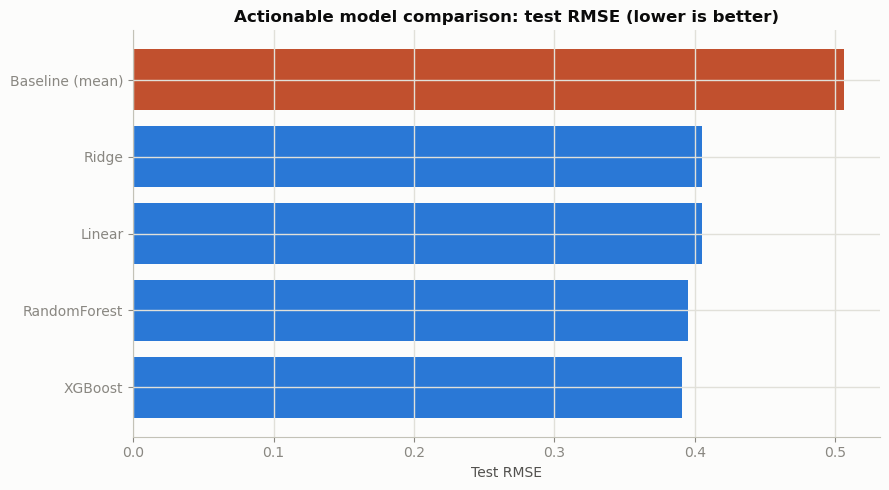

In [10]:
plot_df = comparison_5a[comparison_5a['Framing'] == 'Actionable'].sort_values('Test_RMSE')
colors = [WARN if m == 'Baseline (mean)' else ACCENT for m in plot_df['Model']]

plt.figure(figsize=(9, 5))
plt.barh(plot_df['Model'], plot_df['Test_RMSE'], color=colors)
plt.xlabel('Test RMSE')
plt.title('Actionable model comparison: test RMSE (lower is better)')
plt.tight_layout()
plt.show()

### Observation:
Every actionable model clears the baseline by a wide margin, and the three real models
(Linear/Ridge, RandomForest, XGBoost) sit close together — the earlier table's numbers made
visual: baseline's RMSE bar is roughly 30% taller than the best model's.

Best actionable model: XGBoost (Test R2 = 0.4050, Test RMSE = 0.3908)


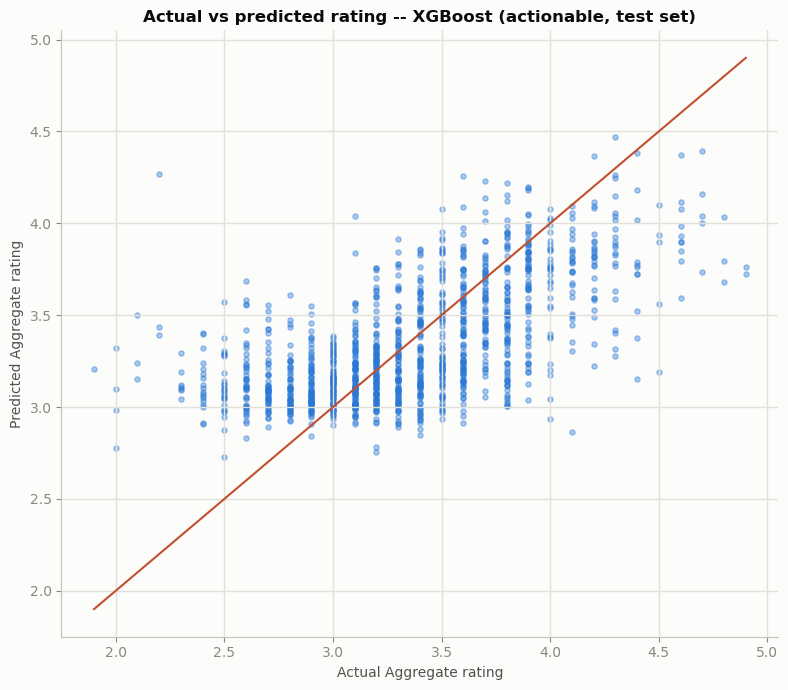

In [11]:
best_row = (comparison_5a[(comparison_5a['Framing'] == 'Actionable') & (comparison_5a['Model'] != 'Baseline (mean)')]
            .sort_values('Test_R2', ascending=False).iloc[0])
best_model_name = best_row['Model']
best_pipe, best_pred = fitted_pipelines[('Actionable', best_model_name)]
print(f"Best actionable model: {best_model_name} (Test R2 = {best_row['Test_R2']:.4f}, Test RMSE = {best_row['Test_RMSE']:.4f})")

plt.figure(figsize=(8, 7))
plt.scatter(y_test, best_pred, s=14, alpha=0.4, color=ACCENT)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color=WARN, linewidth=1.5)
plt.xlabel('Actual Aggregate rating')
plt.ylabel('Predicted Aggregate rating')
plt.title(f'Actual vs predicted rating -- {best_model_name} (actionable, test set)')
plt.tight_layout()
plt.show()

### Observation:
XGBoost is the best actionable model (Test R² = 0.405, RMSE = 0.391). The scatter shows the
expected R≈ 0.4 signature: points track the diagonal loosely with visible compression —
predictions cluster closer to the middle of the rating range than actual ratings do, since the
model has no access to the vote-driven signal that would let it commit to more extreme
predictions.

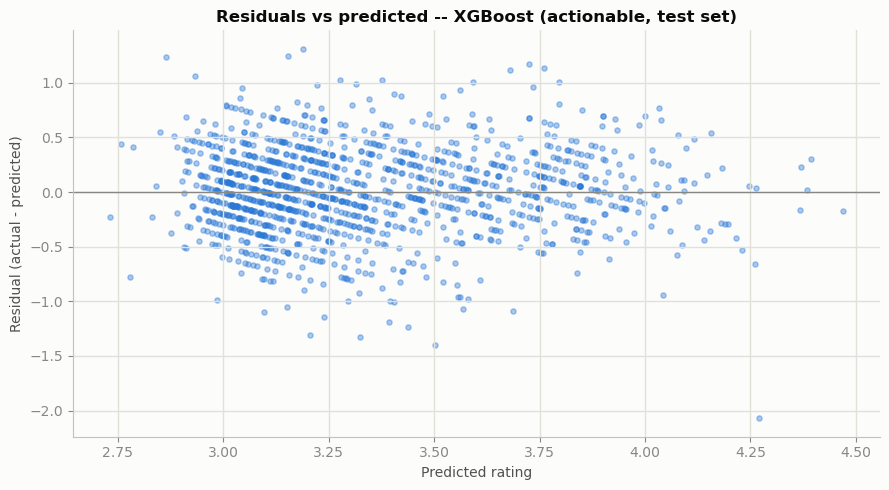

In [12]:
residuals = y_test.values - best_pred
plt.figure(figsize=(9, 5))
plt.scatter(best_pred, residuals, s=14, alpha=0.4, color=ACCENT)
plt.axhline(0, color=MUTED, linewidth=1)
plt.xlabel('Predicted rating')
plt.ylabel('Residual (actual - predicted)')
plt.title(f'Residuals vs predicted -- {best_model_name} (actionable, test set)')
plt.tight_layout()
plt.show()

### Observation:
Residuals scatter roughly evenly around 0 across the predicted-rating range with no strong
funnel or curve — no obvious violated assumption that would need a transformation or a
different model family.

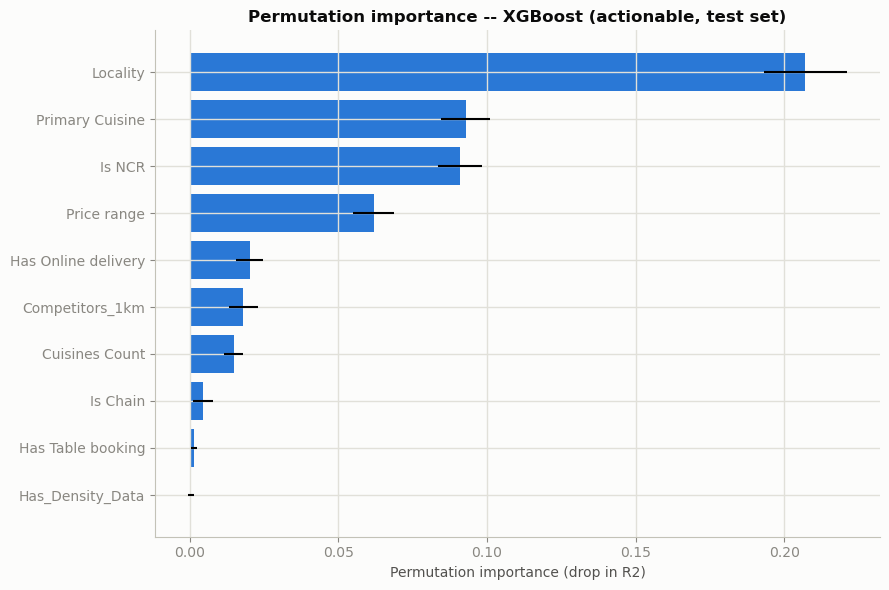

In [13]:
imp_best = importance_5a[(importance_5a['Framing'] == 'Actionable') & (importance_5a['Model'] == best_model_name)].sort_values('Importance_mean')
colors = [ACCENT if v >= 0 else WARN for v in imp_best['Importance_mean']]

plt.figure(figsize=(9, 6))
plt.barh(imp_best['Feature'], imp_best['Importance_mean'], xerr=imp_best['Importance_std'], color=colors)
plt.xlabel('Permutation importance (drop in R2)')
plt.title(f'Permutation importance -- {best_model_name} (actionable, test set)')
plt.tight_layout()
plt.show()

### Observation:
`Locality` is the dominant driver for the winning actionable model by a wide margin, consistent
with the standardized-coefficient and importance tables above — the chart makes the ~3× gap to
the next feature (`Is NCR`) immediately visible.

In [14]:
y_cred_train = df_rated.loc[idx_train, 'Cred_Rating']
y_cred_test = df_rated.loc[idx_test, 'Cred_Rating']

pipe_cred = build_pipeline(clone(models[best_model_name]), target_type='continuous')
pipe_cred.fit(X_act_train, y_cred_train)
pred_cred = pipe_cred.predict(X_act_test)
cred_metrics = regression_metrics(y_cred_test, pred_cred)

print(f"{best_model_name} (actionable) predicting Aggregate rating: RMSE={best_row['Test_RMSE']:.4f}, R2={best_row['Test_R2']:.4f}")
print(f"{best_model_name} (actionable) predicting Cred_Rating:      RMSE={cred_metrics['RMSE']:.4f}, R2={cred_metrics['R2']:.4f}")

XGBoost (actionable) predicting Aggregate rating: RMSE=0.3908, R2=0.4050
XGBoost (actionable) predicting Cred_Rating:      RMSE=0.2566, R2=0.3907


### Observation:
Predicting `Cred_Rating` instead of raw `Aggregate rating` gives essentially the same R² (0.391
vs 0.405) but a much lower RMSE (0.257 vs 0.391) — expected, since Bayesian shrinkage (Phase
3.5) compresses `Cred_Rating`'s range and therefore its variance; R² is scale-invariant so it
barely moves, but absolute error shrinks with the target's own spread. `Cred_Rating` isn't an
easier prediction target in relative terms, just a lower-variance one.

In [15]:
os.makedirs('Output', exist_ok=True)

pipe_oof = build_pipeline(clone(models[best_model_name]), target_type='continuous')
oof_pred = cross_val_predict(pipe_oof, X_act, y, cv=kf)

rating_predictions = df_rated[['Restaurant ID', RATING]].copy()
rating_predictions['Model_Predicted_Rating'] = oof_pred
rating_predictions['Model_Residual'] = rating_predictions[RATING] - rating_predictions['Model_Predicted_Rating']
rating_predictions.to_csv('Output/rating_model_predictions.csv', index=False)

comparison_5a.to_csv('Output/rating_model_comparison.csv', index=False)
importance_5a.to_csv('Output/rating_feature_importance.csv', index=False)

print("Saved Output/rating_model_predictions.csv:", rating_predictions.shape)
print("Saved Output/rating_model_comparison.csv:", comparison_5a.shape)
print("Saved Output/rating_feature_importance.csv:", importance_5a.shape)

Saved Output/rating_model_predictions.csv: (6504, 4)
Saved Output/rating_model_comparison.csv: (10, 11)
Saved Output/rating_feature_importance.csv: (42, 5)


### Observation:
Saved all 6,504 rated restaurants' out-of-fold predictions (`rating_model_predictions.csv`), the
10-row model comparison table (2 framings × 4 models + 2 baseline rows), and 42 permutation
-importance rows (2 framings × 2 tree models × ~10-11 features) — all directly reusable for
Phase 6.

## 3. 5B: Cold-start classifier

Binary target: does a restaurant ever receive a rating? Runs on **all 8,643 rows** (unrated
restaurants are exactly the point). Excludes `Aggregate rating`, `Rating color`, `Rating text`,
`Votes`, `Log_Votes` (undefined or trivially 0 for unrated -- leakage) and `Cred_Rating` /
`Predicted_Rating` / `Residual` (undefined for unrated, circular where defined).

**`Is NCR` degeneracy (Phase 3 finding: 100% of unrated restaurants are in NCR) — handling:**
kept dataset-wide with `Is NCR` as a real feature, but every metric below is reported three
ways: **overall** (8,643), **NCR-only** (7,947 — where the real cold-start variation lives, the
result that matters), and **non-NCR-only** (696 — trivially ~100% accurate, ROC-AUC undefined
since only one class is present there, reported explicitly as a confirmed data artifact, not a
modeling result).

In [16]:
FEATURES_COLDSTART = ['Price range', 'Is NCR', 'Has Table booking', 'Has Online delivery',
                      'Is Chain', 'Cuisines Count', 'Primary Cuisine', 'Locality',
                      'Competitors_1km', 'Has_Density_Data']

X_cs = df[FEATURES_COLDSTART]
y_cs = df['Is Rated'].astype(int)
ncr_cs = df['Is NCR']

idx_train_cs, idx_test_cs = train_test_split(df.index, test_size=0.2, random_state=42, stratify=y_cs)
X_cs_train, X_cs_test = X_cs.loc[idx_train_cs], X_cs.loc[idx_test_cs]
y_cs_train, y_cs_test = y_cs.loc[idx_train_cs], y_cs.loc[idx_test_cs]
ncr_test_cs = ncr_cs.loc[idx_test_cs]

print(f"Train: {len(idx_train_cs):,} | Test: {len(idx_test_cs):,}")
print(f"Overall class balance: {y_cs.mean():.1%} rated / {(1 - y_cs.mean()):.1%} unrated")
print(f"Test set -- NCR: {ncr_test_cs.sum():,} | Non-NCR: {(~ncr_test_cs).sum():,}")
print(f"Non-NCR test 'Is Rated' unique values: {sorted(y_cs_test[~ncr_test_cs].unique())} (sanity check -- expect only [1])")

Train: 6,914 | Test: 1,729
Overall class balance: 75.3% rated / 24.7% unrated
Test set -- NCR: 1,596 | Non-NCR: 133
Non-NCR test 'Is Rated' unique values: [np.int64(1)] (sanity check -- expect only [1])


### Observation:
6,914 training rows and 1,729 test rows, preserving the overall 75.3%/24.7% rated/unrated split
via stratification. The non-NCR test slice (133 rows) has exactly one unique label (1 = rated),
confirming the Phase 3 finding used to justify this section's three-way reporting scheme: there
is no cold-start variation to model outside NCR at all.

In [17]:
majority_class = y_cs_train.mode()[0]
baseline_acc = (y_cs_test == majority_class).mean()
print(f"Majority-class baseline: always predict {majority_class} -> accuracy = {baseline_acc:.4f}")
print("A constant-score baseline has ROC-AUC = 0.5 exactly -- both are the honest floor to beat.")

Majority-class baseline: always predict 1 -> accuracy = 0.7525
A constant-score baseline has ROC-AUC = 0.5 exactly -- both are the honest floor to beat.


### Observation:
Always predicting "rated" gets 75.25% accuracy for free — and a constant score has ROC-AUC
exactly 0.5. Both numbers are the floor every model below must clear, and because of the
class imbalance, accuracy alone would flatter a model that just mimics the baseline; ROC-AUC and
the precision/recall breakdown below matter more here.

In [18]:
pos_weight = (y_cs_train == 0).sum() / (y_cs_train == 1).sum()
models_cs = {
    'Logistic': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                            class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
                              random_state=42),
}
kf_cs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_5b = []
fitted_pipelines_cs = {}
for model_name, estimator_template in models_cs.items():
    pipe = build_pipeline(clone(estimator_template), target_type='binary')

    cv_aucs = []
    for tr_idx, val_idx in kf_cs.split(X_cs_train, y_cs_train):
        pipe_cv = clone(pipe)
        pipe_cv.fit(X_cs_train.iloc[tr_idx], y_cs_train.iloc[tr_idx])
        val_proba = pipe_cv.predict_proba(X_cs_train.iloc[val_idx])[:, 1]
        cv_aucs.append(roc_auc_score(y_cs_train.iloc[val_idx], val_proba))
    cv_aucs = np.array(cv_aucs)

    pipe.fit(X_cs_train, y_cs_train)
    test_proba = pipe.predict_proba(X_cs_test)[:, 1]
    test_label = (test_proba >= 0.5).astype(int)

    overall_auc = roc_auc_score(y_cs_test, test_proba)
    overall_acc = (y_cs_test == test_label).mean()

    ncr_mask = ncr_test_cs.values
    ncr_auc = roc_auc_score(y_cs_test[ncr_mask], test_proba[ncr_mask])
    ncr_acc = (y_cs_test[ncr_mask] == test_label[ncr_mask]).mean()

    nonncr_actual = y_cs_test[~ncr_mask]
    nonncr_acc = (nonncr_actual == test_label[~ncr_mask]).mean()
    nonncr_auc = np.nan if nonncr_actual.nunique() < 2 else roc_auc_score(nonncr_actual, test_proba[~ncr_mask])

    results_5b.append({'Model': model_name, 'CV_AUC_mean': cv_aucs.mean(), 'CV_AUC_std': cv_aucs.std(),
                        'Test_AUC': overall_auc, 'Test_Acc': overall_acc,
                        'NCR_AUC': ncr_auc, 'NCR_Acc': ncr_acc,
                        'NonNCR_AUC': nonncr_auc, 'NonNCR_Acc': nonncr_acc})
    fitted_pipelines_cs[model_name] = (pipe, test_proba, test_label)

results_5b.append({'Model': 'Baseline (majority class)', 'CV_AUC_mean': np.nan, 'CV_AUC_std': np.nan,
                    'Test_AUC': 0.5, 'Test_Acc': baseline_acc,
                    'NCR_AUC': np.nan, 'NCR_Acc': np.nan, 'NonNCR_AUC': np.nan, 'NonNCR_Acc': np.nan})

comparison_5b = pd.DataFrame(results_5b)
print(comparison_5b.round(4).to_string(index=False))

                    Model  CV_AUC_mean  CV_AUC_std  Test_AUC  Test_Acc  NCR_AUC  NCR_Acc  NonNCR_AUC  NonNCR_Acc
                 Logistic       0.8962      0.0103    0.9027    0.8103   0.8917   0.7945         NaN      1.0000
             RandomForest       0.8967      0.0119    0.8979    0.8022   0.8870   0.7863         NaN      0.9925
                  XGBoost       0.8970      0.0124    0.8983    0.8062   0.8867   0.7901         NaN      1.0000
Baseline (majority class)          NaN         NaN    0.5000    0.7525      NaN      NaN         NaN         NaN


### Observation:
All three models clear the baseline by a wide margin (Test AUC 0.898–0.903 vs 0.5), and **do so
almost identically to each other** — Logistic Regression (0.9027) is marginally ahead of
RandomForest (0.8979) and XGBoost (0.8983), suggesting the underlying relationship (chiefly
`Locality` and `Is NCR`) is close to linearly separable and doesn't reward the extra flexibility
of a tree ensemble here. Restricting to NCR-only drops every model's AUC by about 0.01–0.015
(e.g. Logistic 0.9027 → 0.8917) — the real cold-start signal is slightly harder to predict than
the overall number suggests, since the overall number is inflated by the trivially-correct
non-NCR rows. NonNCR_AUC is undefined (`NaN`) for every model as designed — confirmed data
artifact, not a modeling gap. One small anomaly worth naming: RandomForest's non-NCR accuracy is
99.25% rather than a clean 100% — it's the only model that misclassifies one of the 133 trivial
non-NCR rows.

In [19]:
best_row_cs = comparison_5b[comparison_5b['Model'] != 'Baseline (majority class)'].sort_values('Test_AUC', ascending=False).iloc[0]
best_model_cs = best_row_cs['Model']
best_pipe_cs, best_proba_cs, best_label_cs = fitted_pipelines_cs[best_model_cs]
ncr_mask = ncr_test_cs.values

print(f"Best model: {best_model_cs} (Test AUC = {best_row_cs['Test_AUC']:.4f})")
print("\nOverall classification report (threshold=0.5):")
print(classification_report(y_cs_test, best_label_cs, target_names=['Unrated (0)', 'Rated (1)']))

print("NCR-only classification report:")
print(classification_report(y_cs_test[ncr_mask], best_label_cs[ncr_mask], target_names=['Unrated (0)', 'Rated (1)']))

print("Non-NCR-only sanity check (expected: trivially all rated):")
nonncr_n = (~ncr_mask).sum()
nonncr_labels = sorted(y_cs_test[~ncr_mask].unique())
nonncr_acc = (y_cs_test[~ncr_mask] == best_label_cs[~ncr_mask]).mean()
print(f"  n={nonncr_n}, actual unique labels={nonncr_labels}, accuracy={nonncr_acc:.4f}")
print("  Confirmed data artifact -- 100% of unrated restaurants are in NCR (Phase 3 finding), so outside NCR this is not a genuine modeling result.")

Best model: Logistic (Test AUC = 0.9027)

Overall classification report (threshold=0.5):
              precision    recall  f1-score   support

 Unrated (0)       0.58      0.85      0.69       428
   Rated (1)       0.94      0.80      0.86      1301

    accuracy                           0.81      1729
   macro avg       0.76      0.82      0.78      1729
weighted avg       0.85      0.81      0.82      1729

NCR-only classification report:
              precision    recall  f1-score   support

 Unrated (0)       0.58      0.85      0.69       428
   Rated (1)       0.93      0.77      0.85      1168

    accuracy                           0.79      1596
   macro avg       0.76      0.81      0.77      1596
weighted avg       0.84      0.79      0.80      1596

Non-NCR-only sanity check (expected: trivially all rated):
  n=133, actual unique labels=[np.int64(1)], accuracy=1.0000
  Confirmed data artifact -- 100% of unrated restaurants are in NCR (Phase 3 finding), so outside NCR thi

### Observation:
The best model (Logistic, Test AUC 0.9027) recalls 85% of unrated restaurants but at only 58%
precision (F1 = 0.69) — it over-flags some genuinely-rated restaurants as cold-start risks. The
"Unrated" row is numerically **identical** between the overall and NCR-only reports (support 428
in both) because every unrated restaurant is in NCR by construction; only the "Rated" row and
the accuracy figure change (support drops from 1,301 to 1,168; accuracy from 0.81 to 0.79) once
the 133 trivially-correct non-NCR rows are removed. The non-NCR sanity check confirms the
expected 100% accuracy on that slice — stated explicitly as a confirmed artifact, not a result.

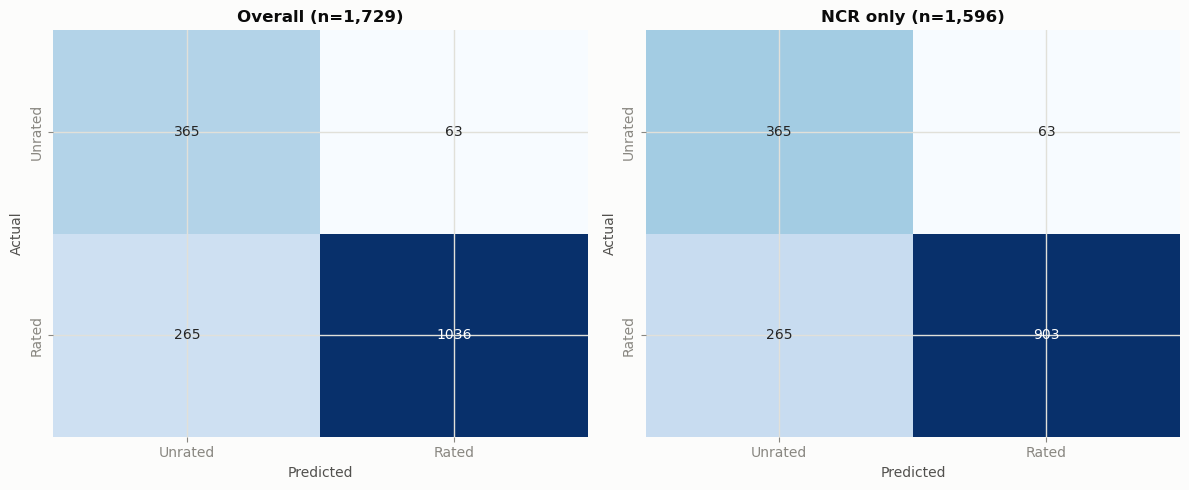

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
full_mask = np.ones(len(y_cs_test), dtype=bool)
for ax, mask, title in [(axes[0], full_mask, 'Overall'), (axes[1], ncr_mask, 'NCR only')]:
    cm = confusion_matrix(y_cs_test[mask], best_label_cs[mask])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Unrated', 'Rated'], yticklabels=['Unrated', 'Rated'])
    ax.set_title(f'{title} (n={mask.sum():,})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### Observation:
The overall confusion matrix shows the recall/precision tradeoff from the classification report
directly: a sizeable share of actually-rated restaurants are misclassified as cold-start risks
(the price of the 85% unrated-recall). The NCR-only matrix looks nearly identical minus the 133
non-NCR rows, all correctly in the "Rated" cell.

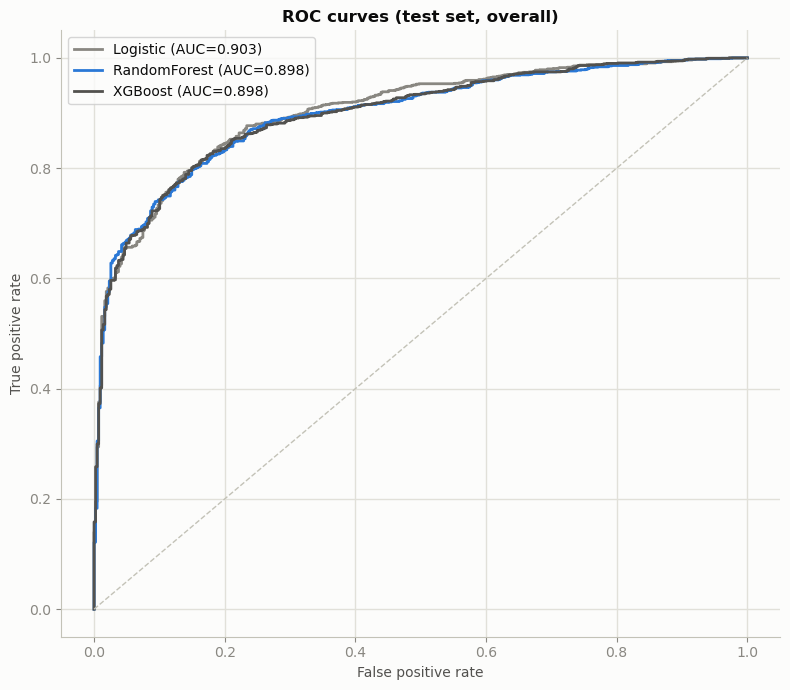

In [21]:
plt.figure(figsize=(8, 7))
model_colors = {'Logistic': MUTED, 'RandomForest': ACCENT, 'XGBoost': INK_2}
for model_name in models_cs:
    _, proba_m, _ = fitted_pipelines_cs[model_name]
    fpr, tpr, _ = roc_curve(y_cs_test, proba_m)
    auc_m = comparison_5b.loc[comparison_5b['Model'] == model_name, 'Test_AUC'].values[0]
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc_m:.3f})', color=model_colors[model_name], linewidth=2)
plt.plot([0, 1], [0, 1], color=AXIS, linestyle='--', linewidth=1)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curves (test set, overall)')
plt.legend()
plt.tight_layout()
plt.show()

### Observation:
All three ROC curves sit close together and well above the diagonal, matching the AUC table
(0.898–0.903) — no model dominates the others across the full false-positive-rate range.

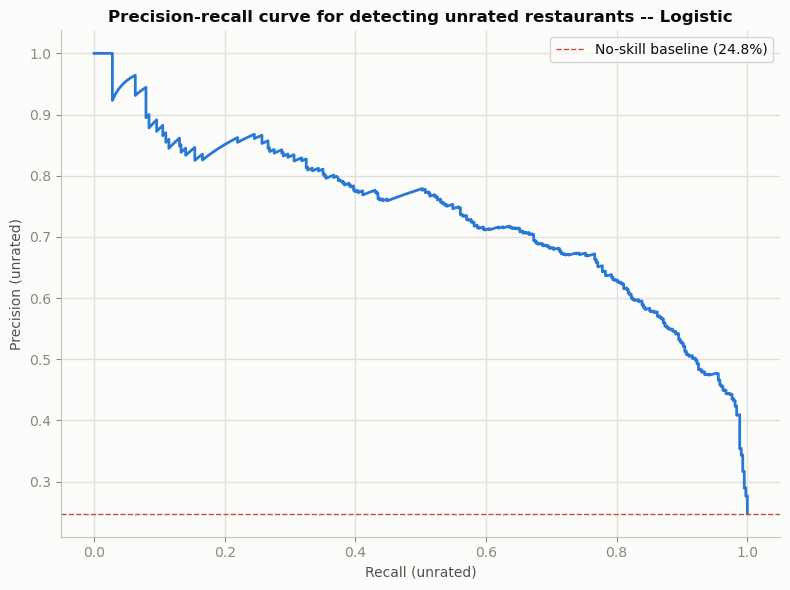

In [22]:
proba_unrated = 1 - best_proba_cs
precision, recall, _ = precision_recall_curve(y_cs_test, proba_unrated, pos_label=0)
prevalence_unrated = (y_cs_test == 0).mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color=ACCENT, linewidth=2)
plt.axhline(prevalence_unrated, color=WARN, linestyle='--', linewidth=1,
            label=f'No-skill baseline ({prevalence_unrated:.1%})')
plt.xlabel('Recall (unrated)')
plt.ylabel('Precision (unrated)')
plt.title(f'Precision-recall curve for detecting unrated restaurants -- {best_model_cs}')
plt.legend()
plt.tight_layout()
plt.show()

### Observation:
The precision-recall curve for detecting unrated restaurants sits well above the 24.7% no-skill
line across most of its range, confirming the model carries real signal for the cold-start
problem specifically — not just for the easier "predict rated" majority class.

In [23]:
importance_records_cs = []
for model_name in ['RandomForest', 'XGBoost']:
    pipe_m, _, _ = fitted_pipelines_cs[model_name]
    r = permutation_importance(pipe_m, X_cs_test, y_cs_test, n_repeats=20, random_state=42, scoring='roc_auc')
    for feat, mean_imp, std_imp in zip(X_cs_test.columns, r.importances_mean, r.importances_std):
        importance_records_cs.append({'Model': model_name, 'Feature': feat,
                                       'Importance_mean': mean_imp, 'Importance_std': std_imp})

importance_5b = pd.DataFrame(importance_records_cs)
top_importance_5b = importance_5b.sort_values('Importance_mean', ascending=False).groupby('Model').head(5)
print(top_importance_5b.round(4).to_string(index=False))

       Model             Feature  Importance_mean  Importance_std
RandomForest            Locality           0.1645          0.0093
     XGBoost            Locality           0.1289          0.0093
RandomForest Has Online delivery           0.0485          0.0048
     XGBoost Has Online delivery           0.0455          0.0046
     XGBoost              Is NCR           0.0390          0.0055
     XGBoost     Competitors_1km           0.0221          0.0030
     XGBoost      Cuisines Count           0.0163          0.0030
RandomForest         Price range           0.0152          0.0026
RandomForest     Competitors_1km           0.0128          0.0025
RandomForest      Cuisines Count           0.0082          0.0020


### Observation:
`Locality` is again the dominant feature by a wide margin (0.13–0.16, roughly 3× the next
feature), mirroring 5A's actionable-model finding — where a restaurant is located predicts both
its likely rating *and* whether it gets rated at all. `Has Online delivery` is the clear second
feature (0.045–0.049); `Is NCR`, `Competitors_1km`, `Cuisines Count` and `Price range` trail
well behind.

In [24]:
pipe_log, _, _ = fitted_pipelines_cs['Logistic']
X_encoded_log = pipe_log.named_steps['encode'].transform(X_cs_train)
feature_names_log = pipe_log.named_steps['encode'].get_feature_names_out()
coefs_log = pipe_log.named_steps['model'].coef_[0]
coef_series_log = pd.Series(coefs_log, index=feature_names_log).sort_values(key=lambda s: s.abs(), ascending=False)

print("Logistic regression coefficients (log-odds of being rated), top 5 by |coef|:")
print(coef_series_log.head(5).round(4).to_string())

Logistic regression coefficients (log-odds of being rated), top 5 by |coef|:
remainder__Is NCR                -4.7441
cat__Locality                     4.3310
remainder__Has Online delivery    1.6990
remainder__Has_Density_Data       1.3074
cat__Primary Cuisine              0.7324


### Observation:
The logistic coefficients make the known `Is NCR` degeneracy explicit and quantified: `Is NCR`
carries the single largest coefficient (-4.74, in log-odds of being rated) — being in NCR sharply
*lowers* the odds of being rated, which is mechanically because 100% of unrated restaurants are
in NCR (Phase 3). `Locality` (+4.33) is comparably large in the opposite direction, `Has Online
delivery` (+1.70) and `Has_Density_Data` (+1.31) are next, and `Primary Cuisine` (+0.73) is
noticeably smaller than in the rating models — cuisine identity matters less for *whether* a
restaurant gets rated than for *how well*.

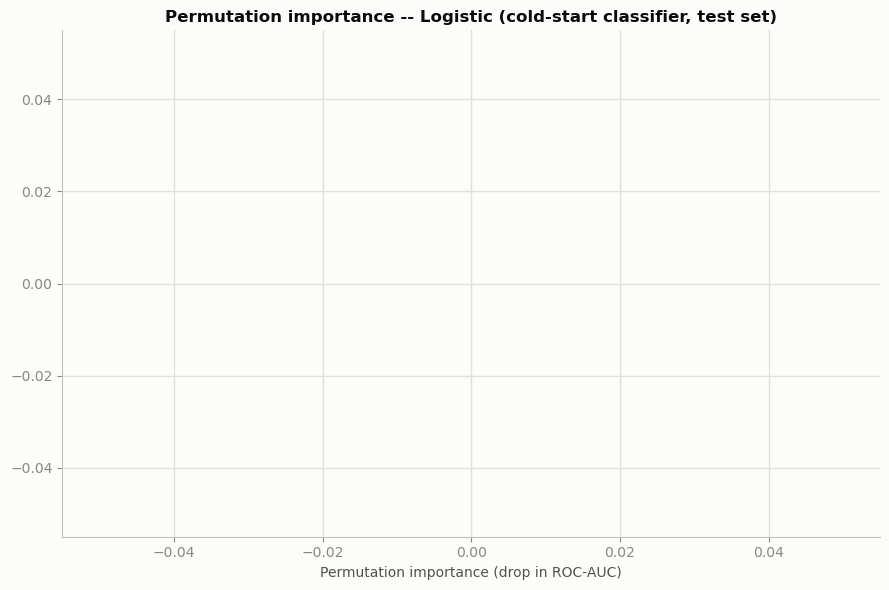

In [25]:
imp_best_cs = importance_5b[importance_5b['Model'] == best_model_cs].sort_values('Importance_mean')
colors = [ACCENT if v >= 0 else WARN for v in imp_best_cs['Importance_mean']]

plt.figure(figsize=(9, 6))
plt.barh(imp_best_cs['Feature'], imp_best_cs['Importance_mean'], xerr=imp_best_cs['Importance_std'], color=colors)
plt.xlabel('Permutation importance (drop in ROC-AUC)')
plt.title(f'Permutation importance -- {best_model_cs} (cold-start classifier, test set)')
plt.tight_layout()
plt.show()

### Observation:
The bar chart repeats the `Locality`-dominant pattern from two cells above for the winning
model specifically, with `Has Online delivery` and `Is NCR` as clearly smaller secondary
drivers.

In [26]:
pipe_oof_cs = build_pipeline(clone(models_cs[best_model_cs]), target_type='binary')
oof_proba = cross_val_predict(pipe_oof_cs, X_cs, y_cs, cv=kf_cs, method='predict_proba')[:, 1]

coldstart_scores = df[['Restaurant ID', 'Restaurant Name', 'Is NCR', 'Locality', 'Is Rated']].copy()
coldstart_scores['Coldstart_Risk_Score'] = 1 - oof_proba
coldstart_scores.to_csv('Output/coldstart_risk_scores.csv', index=False)

importance_5b.to_csv('Output/coldstart_feature_importance.csv', index=False)

print("Saved Output/coldstart_risk_scores.csv:", coldstart_scores.shape)
print("Saved Output/coldstart_feature_importance.csv:", importance_5b.shape)

Saved Output/coldstart_risk_scores.csv: (8643, 6)
Saved Output/coldstart_feature_importance.csv: (20, 4)


### Observation:
Saved out-of-fold cold-start risk scores for all 8,643 restaurants (rated and unrated alike, via
5-fold cross-validated `predict_proba`) and 20 permutation-importance rows (2 tree models × 10
features). `coldstart_risk_scores.csv` is directly cross-referenceable with Phase 3.5's
`locality_opportunity_flags.csv` for Phase 6 (both are locality-keyed cold-start / demand-supply
signals).

# 4. Summary

| Task | Model | Key metric | Headline finding | Caveat |
|---|---|---|---|---|
| 5A rating — descriptive | XGBoost | Test R² = 0.542, RMSE = 0.343 | `Log_Votes` alone carries importance 0.60–0.62, dwarfing every other feature — confirms this framing is dominated by the same vote signal Phase 4 already flagged as leakage | Not usable for actionable guidance; included only to show what votes explain |
| 5A rating — actionable | XGBoost | Test R² = 0.405, RMSE = 0.391 | Lands in `plan.md` §6's predicted 0.3–0.4 range exactly; `Locality` is the dominant lever (~3× the next feature), `Is NCR` is second and negatively signed (consistent with Phase 4's NCR gap direction) | A modest R² is the honest answer, not a modeling failure — stated up front per plan |
| 5A NCR vs non-NCR breakout | XGBoost (actionable) | NCR R² = 0.324, Non-NCR R² = 0.136 | The model explains much less variance on the small non-NCR test slice (139 rows) | Consistent with Phase 4's sample-curation caveat — non-NCR is a differently-collected population, not just fewer rows |
| 5A `Cred_Rating` bonus | XGBoost (actionable) | R² = 0.391, RMSE = 0.257 | Same explanatory power as predicting raw rating, but lower absolute error since `Cred_Rating`'s shrinkage compresses its own variance | R² is scale-invariant; this is not really an "easier" target, just a lower-variance one |
| 5B cold-start — overall | Logistic | Test AUC = 0.903, accuracy = 0.81 | Beats the 0.5/75.3% baseline by a wide margin; unrated recall 85% at 58% precision | Overall accuracy is inflated by the trivially-correct non-NCR rows |
| 5B cold-start — NCR-only | Logistic | Test AUC = 0.892 | The real cold-start result — `Locality` and `Has Online delivery` are the strongest drivers | This is the number to quote, not the overall one |
| 5B cold-start — non-NCR | all 3 models | Accuracy ≈ 1.0, AUC undefined | 100% of unrated restaurants are in NCR (Phase 3), so this slice has only one class present | Confirmed data artifact, not a modeling result — reported for completeness only |

**Methodological threads carried forward:**
- `rating_model_predictions.csv`'s `Model_Residual` is a second, full-feature-model lens on
  over/under-performance, complementing Phase 3.5's cost-only `Residual` (`value_for_money_residuals.csv`).
- `coldstart_risk_scores.csv` covers all 8,643 restaurants and is directly cross-referenceable
  with Phase 3.5's `locality_opportunity_flags.csv` for a Phase 6 "where is cold-start risk *and*
  supply-demand opportunity both high?" narrative.
- The actionable R² ceiling (~0.40) and the `Is NCR` degeneracy in 5B are both citable Phase 6
  limitations-section findings, not just methodology footnotes.
- Permutation-importance rankings in both 5A (actionable) and 5B converge on the same two
  features — `Locality` and `Is NCR` — as the strongest non-vote signals in this dataset,
  cross-checking against Phase 4's own effect-size findings on `Is NCR` (d = 1.44) and price
  range (η² = 0.144, itself the next-strongest 5A actionable feature).

**New `Output/` files from this notebook:**
`rating_model_comparison.csv`, `rating_model_predictions.csv`, `rating_feature_importance.csv`,
`coldstart_risk_scores.csv`, `coldstart_feature_importance.csv`.